In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
import datetime
from torchsummary import summary
import os
import pandas as pd
import numpy as np
from random import randint, random

In [6]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [7]:
def train_one_epoch(model, trainloader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def validate_one_epoch(model, testloader, criterion, device):
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = val_loss / len(testloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc



In [8]:
def load_checkpoint(model, optimizer, checkpoint_path):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state_dict'])

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch']
    best_val_loss = checkpoint['val_loss']

    print(f"Checkpoint loaded: {checkpoint_path} (Epoch {start_epoch}, Best Val Loss: {best_val_loss:.4f})")

    return model, optimizer, start_epoch, best_val_loss

In [9]:
def train_and_evaluate_model(
    model,
    trainloader,
    testloader,
    device,
    num_epochs=10,
    lr=0.001,
    model_name="UnnamedModel",
    csv_path="results.csv",
    patience=3,
    save_model=True,
    save_every=5,
    resume_from=None,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    results = []
    best_val_loss = float("inf")
    epochs_no_improve = 0
    start_epoch = 0
    best_checkpoint = None
    last_checkpoint = None
    early_stopping_triggered = False

    if resume_from:
        model, optimizer, start_epoch, best_val_loss = load_checkpoint(model, optimizer, resume_from)

    for epoch in range(start_epoch, num_epochs):
        start_time = time.time()

        epoch_loss, epoch_acc = train_one_epoch(
            model, trainloader, optimizer, criterion, device
        )

        val_loss, val_acc = validate_one_epoch(
            model, testloader, criterion, device
        )

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1} /// acc: {epoch_acc:.4f} /// loss: {epoch_loss:.4f} /// "
              f"val_acc: {val_acc:.4f} /// val_loss: {val_loss:.4f} /// time: {epoch_time:.2f}s")

        results.append({
            "epoch": epoch + 1,
            "model": model_name,
            "train_accuracy": epoch_acc,
            "train_loss": epoch_loss,
            "val_accuracy": val_acc,
            "val_loss": val_loss,
            "epoch_time_sec": epoch_time
        })

        last_checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }

        if (epoch + 1) % save_every == 0:
            filename = f"models/{model_name}_checkpoint.pt"
            torch.save(last_checkpoint, filename)
            print(f"Checkpoint saved as {filename}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            if save_model:
                best_checkpoint = {
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss,
                }
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                early_stopping_triggered = True
                if best_checkpoint:
                    best_filename = f"models/{model_name}_earlystop.pt"
                    torch.save(best_checkpoint, best_filename)
                    print(f"Best model after early stopping saved as {best_filename}")
                break

    if not early_stopping_triggered:
        final_filename = f"models/{model_name}.pt"
        torch.save(best_checkpoint, final_filename)
        print(f"Final model saved as {final_filename}")

    if csv_path:
        df_results = pd.DataFrame(results)
        if os.path.exists(csv_path):
            df_existing = pd.read_csv(csv_path)
            df_results = pd.concat([df_existing, df_results], ignore_index=True)
        df_results.to_csv(csv_path, index=False)

    return df_results, model


In [10]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [11]:
class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10) 
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BasicCNN().to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,496
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
         MaxPool2d-8             [-1, 64, 8, 8]               0
            Conv2d-9            [-1, 128, 8, 8]          73,856
      BatchNorm2d-10            [-1, 128, 8, 8]             256
             ReLU-11            [-1, 128, 8, 8]               0
        MaxPool2d-12            [-1, 128, 4, 4]               0
          Flatten-13                 [-1, 2048]               0
           Linear-14                  [

In [9]:
# trained_model = train_and_evaluate_model(
#     model=model,
#     trainloader=train_loader,
#     testloader=test_loader,
#     device=device,
#     num_epochs=20,
#     lr=0.001,
#     model_name="CIFAR10_BasicCNN",
#     save_model=True,
#     save_every=5
# )

In [79]:
df_baseline = pd.read_csv("results.csv")
df_baseline

,epoch,model,train_accuracy,train_loss,val_accuracy,val_loss,epoch_time_sec
0,1,CIFAR10_BasicCNN,0.79342,0.611352,0.8099,0.550488,39.200613
1,2,CIFAR10_BasicCNN,0.79908,0.597627,0.7934,0.598256,40.465788
2,3,CIFAR10_BasicCNN,0.80220,0.588098,0.8010,0.579646,42.558519
3,4,CIFAR10_BasicCNN,0.80624,0.573590,0.8105,0.552941,40.530883


In [12]:
class DynamicCNN(nn.Module):
    def __init__(self, num_filters=128, dropout=0.158791, num_blocks=5, hidden_size=492):
        super(DynamicCNN, self).__init__()
        layers = []

        in_channels = 3
        for i in range(num_blocks):
            layers.extend([
                nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1),
                nn.BatchNorm2d(num_filters),
                nn.ReLU(),
                nn.MaxPool2d(2, 2)
            ])
            in_channels = num_filters
            num_filters *= 2

        self.features = nn.Sequential(*layers)

        final_size = 32 // (2 ** num_blocks) 
        flattened_size = in_channels * final_size * final_size

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, hidden_size),  
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 10)  
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [13]:
model = DynamicCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 32, 32]           3,584
       BatchNorm2d-2          [-1, 128, 32, 32]             256
              ReLU-3          [-1, 128, 32, 32]               0
         MaxPool2d-4          [-1, 128, 16, 16]               0
            Conv2d-5          [-1, 256, 16, 16]         295,168
       BatchNorm2d-6          [-1, 256, 16, 16]             512
              ReLU-7          [-1, 256, 16, 16]               0
         MaxPool2d-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 512, 8, 8]       1,180,160
      BatchNorm2d-10            [-1, 512, 8, 8]           1,024
             ReLU-11            [-1, 512, 8, 8]               0
        MaxPool2d-12            [-1, 512, 4, 4]               0
           Conv2d-13           [-1, 1024, 4, 4]       4,719,616
      BatchNorm2d-14           [-1, 102

In [12]:
def get_num_epochs(gen, max_gen):
    if gen < max_gen * 0.3:
        return 1
    elif gen < max_gen * 0.5:
        return 5
    elif gen < max_gen * 0.8:
        return 10
    else:
        return 15

In [3]:
1e-2 == 0.01

True

In [ ]:

# === Параметри DE ===
F = 0.8          
CR = 0.9         
POP_SIZE = 10    
MAX_GEN = 8     

bounds = [
    (1e-5, 1e-2),   # Learning rate
    (0.1, 0.7),     # Dropout
    (16, 128),      # Число фильтров
    (1, 5),         # Количество блоков
    (64, 512)       # Число нейронов в скрытом слое
]

def initialize_population(pop_size, bounds):
    population = []
    for _ in range(pop_size):
        individual = [np.random.uniform(low, high) for (low, high) in bounds]
        population.append(individual)
    return population


def mutate(population, idx):
    a, b, c = np.random.choice([i for i in range(len(population)) if i != idx], 3, replace=False)
    mutant = np.array(population[a]) + F * (np.array(population[b]) - np.array(population[c]))
    mutant = np.clip(mutant, [low for (low, high) in bounds], [high for (low, high) in bounds])
    return mutant

def crossover(target, mutant):
    j_rand = randint(0, len(target) - 1)
    trial = []

    for i in range(len(target)):
        if random() < CR or i == j_rand:
            trial.append(mutant[i])
        else:
            trial.append(target[i])
    return trial



In [ ]:
def evaluate(individual, num_epochs=10, patience=3):

    lr, dropout, num_filters, num_blocks, hidden_size = individual
    num_filters = int(round(num_filters))
    num_blocks = int(round(num_blocks))
    hidden_size = int(round(hidden_size))

    model = DynamicCNN(num_filters=num_filters, dropout=dropout, num_blocks=num_blocks, hidden_size=hidden_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_val_acc = 0
    epochs_no_improve = 0

    for epoch in range(num_epochs):

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()


                _, preds = outputs.max(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)


        val_loss /= len(test_loader)
        val_acc = correct / total

        print(f"Epoch {epoch+1} - LR: {lr:.5f}, Dropout: {dropout:.3f}, Filters: {num_filters}, Blocks: {num_blocks}, Neurons: {hidden_size}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} with best loss: {best_val_loss:.4f}, best accuracy: {best_val_acc:.4f}")
                break

    print(f"Best Loss: {best_val_loss:.4f}, Best Accuracy: {best_val_acc:.4f}")
    return best_val_loss, best_val_acc


In [24]:
log_data = []

In [ ]:
def log_result(generation, individual_idx, individual, val_loss, val_acc, num_epochs):
    global log_data
    log_data.append([
        generation, 
        individual_idx, 
        individual[0],  # lr
        individual[1],  # dropout
        int(round(individual[2])),  # filters
        int(round(individual[3])),  # blocks
        int(round(individual[4])),  # neurons
        val_loss, 
        val_acc,
        num_epochs
    ])

In [ ]:
def save_results_to_csv(filename="de_results.csv"):
    global log_data

    df = pd.DataFrame(log_data, columns=[
        "generation", "individual_idx", "lr", "dropout", "filters", "blocks", "neurons", "val_loss", "val_acc", "num_epochs"
    ])

    df.to_csv(filename, index=False)
    print(f"Results saved in: {filename}")

In [ ]:
def differential_evolution():
    global log_data

    population = initialize_population(POP_SIZE, bounds)
    fitness = [evaluate(ind, num_epochs=1)[0] for ind in population]

    # Загрузка начальной популяции из файла
    # best_individuals_path = "best_individuals_gen5.csv"  
    # best_individuals = pd.read_csv(best_individuals_path)
    # population = best_individuals[['lr', 'dropout', 'filters', 'blocks', 'neurons']].values.tolist()
    # fitness = best_individuals['val_loss'].tolist()

    for gen in range(5, MAX_GEN):
        num_epochs = get_num_epochs(gen, MAX_GEN)
        print(f"\n=== Generation {gen+1} (Epochs: {num_epochs}) ===")
        new_population = []

        for i in range(POP_SIZE):

            mutant = mutate(population, i)
            trial = crossover(population[i], mutant)

            trial_loss, trial_acc = evaluate(trial, num_epochs=num_epochs)

            if not np.isfinite(trial_loss):
                print(f"Invalid loss detected: {trial_loss}, skipping individual.")
                continue

            log_result(gen + 1, i + 1, trial, trial_loss, trial_acc, num_epochs)

            if trial_loss < fitness[i]:
                print(f"Improved: {fitness[i]:.4f} -> {trial_loss:.4f}")
                new_population.append(trial)
                fitness[i] = trial_loss
            else:
                new_population.append(population[i])

        population = new_population

        best_idx = np.argmin(fitness)
        best_individual = population[best_idx]
        best_score = fitness[best_idx]
        print(f"Best Loss in Generation {gen+1}: {best_score:.4f} with params: {best_individual}")

        if (gen + 1) % 2 == 0:
            save_results_to_csv(f"de_results_gen{gen+1}.csv")

    best_idx = np.argmin(fitness)
    best_individual = population[best_idx]
    best_score = fitness[best_idx]
    print(f"\nBest Overall Loss: {best_score:.4f} with params: {best_individual}")

    return best_individual, best_score


In [ ]:
best_individual, best_score = differential_evolution()
save_results_to_csv("de_results.csv")
print(f"\nBest hyperparameters: {best_individual}")
print(f"Best validation accuracy: {best_score:.4f}")


Epoch 1 - LR: 0.00844, Dropout: 0.392, Filters: 65, Blocks: 1, Neurons: 366, Val Loss: 2.2617, Val Acc: 0.1171
Best Loss: 2.2617, Best Accuracy: 0.1171
Epoch 1 - LR: 0.00628, Dropout: 0.520, Filters: 24, Blocks: 2, Neurons: 204, Val Loss: 1.8760, Val Acc: 0.2278
Best Loss: 1.8760, Best Accuracy: 0.2278
Epoch 1 - LR: 0.00882, Dropout: 0.655, Filters: 123, Blocks: 1, Neurons: 399, Val Loss: 2.3036, Val Acc: 0.1000
Best Loss: 2.3036, Best Accuracy: 0.1000
Epoch 1 - LR: 0.00635, Dropout: 0.697, Filters: 38, Blocks: 2, Neurons: 232, Val Loss: 2.2125, Val Acc: 0.1499
Best Loss: 2.2125, Best Accuracy: 0.1499
Epoch 1 - LR: 0.00158, Dropout: 0.192, Filters: 27, Blocks: 1, Neurons: 119, Val Loss: 1.5003, Val Acc: 0.4574
Best Loss: 1.5003, Best Accuracy: 0.4574
Epoch 1 - LR: 0.00465, Dropout: 0.366, Filters: 102, Blocks: 5, Neurons: 414, Val Loss: 1.7091, Val Acc: 0.3244
Best Loss: 1.7091, Best Accuracy: 0.3244
Epoch 1 - LR: 0.00124, Dropout: 0.118, Filters: 88, Blocks: 2, Neurons: 176, Val Loss:

In [29]:
best_individual, best_score = differential_evolution()
save_results_to_csv("de_results.csv")
print(f"\nBest hyperparameters: {best_individual}")
print(f"Best validation accuracy: {best_score:.4f}")


=== Generation 6 (Epochs: 10) ===
Epoch 1 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 1.9463, Val Acc: 0.1897
Epoch 2 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 1.9103, Val Acc: 0.2060
Epoch 3 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 1.7420, Val Acc: 0.2788
Epoch 4 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 1.5068, Val Acc: 0.3820
Epoch 5 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 1.2960, Val Acc: 0.4843
Epoch 6 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 1.2223, Val Acc: 0.5474
Epoch 7 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 1.0174, Val Acc: 0.6391
Epoch 8 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neurons: 512, Val Loss: 0.9039, Val Acc: 0.6901
Epoch 9 - LR: 0.00698, Dropout: 0.534, Filters: 122, Blocks: 5, Neuro

KeyboardInterrupt: 

In [ ]:
file_path = "de_results_gen8.csv"
df = pd.read_csv(file_path)

In [ ]:
best_individuals = df.loc[df.groupby('individual_idx')['val_loss'].idxmin()]

best_individuals = best_individuals.sort_values(by='individual_idx')

best_individuals_path = "best_individuals_gen8.csv"
best_individuals.to_csv(best_individuals_path, index=False)

In [78]:
best_individuals.sort_values(by='val_acc', ascending=False)

,generation,individual_idx,lr,dropout,filters,blocks,neurons,val_loss,val_acc,num_epochs
2,6,3,0.000522,0.158791,128,5,492,0.460625,0.8454,10
3,6,4,0.000672,0.339193,113,5,383,0.489873,0.8387,10
10,7,1,0.001052,0.246897,116,4,512,0.489882,0.8335,10
29,8,10,0.001748,0.128515,116,5,502,0.495310,0.8312,10
24,8,5,0.001748,0.100000,128,4,437,0.514959,0.8288,10
16,7,7,0.000618,0.440137,113,4,399,0.527553,0.8225,10
11,7,2,0.003068,0.339568,122,5,276,0.555302,0.8169,10
8,6,9,0.001223,0.247126,121,3,347,0.658900,0.7826,10
27,8,8,0.009139,0.268542,126,5,381,0.676121,0.7719,10
25,8,6,0.002658,0.395784,122,4,149,0.728584,0.7593,10


In [77]:
best_individuals.sort_values(by='val_acc', ascending=False).head(1)

,generation,individual_idx,lr,dropout,filters,blocks,neurons,val_loss,val_acc,num_epochs
2,6,3,0.000522,0.158791,128,5,492,0.460625,0.8454,10


In [ ]:
file1 = "de_results_gen5.csv"
file2 = "de_results_gen8.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

combined_df = pd.concat([df1, df2], ignore_index=True)

combined_df.to_csv("de_results.csv", index=False)

In [14]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import seaborn as sns

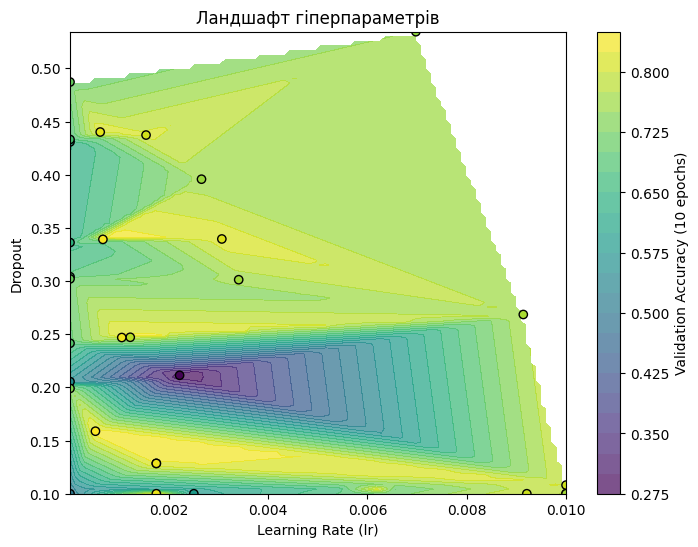

In [21]:
df = pd.read_csv("de_results.csv")
filtered_df = df[df['num_epochs'] == 10]

x = filtered_df['lr'].values
y = filtered_df['dropout'].values
z = filtered_df['val_acc'].values

xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
xi, yi = np.meshgrid(xi, yi)

zi = griddata((x, y), z, (xi, yi), method='linear')

plt.figure(figsize=(8, 6))
contour = plt.contourf(xi, yi, zi, levels=25, cmap='viridis', alpha=0.7)
plt.scatter(x, y, c=z, cmap='viridis', edgecolor='k')  
plt.colorbar(contour, label='Validation Accuracy (10 epochs)')
plt.title("Ландшафт гіперпараметрів")
plt.xlabel("Learning Rate (lr)")
plt.ylabel("Dropout")
plt.show()

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

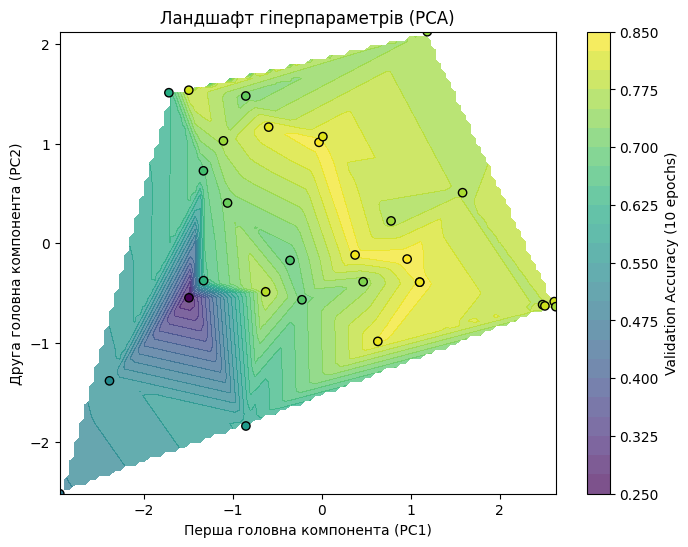

In [ ]:

filtered_df = df[df['num_epochs'] == 10]

params = filtered_df[['lr', 'dropout', 'filters', 'blocks', 'neurons']].values
val_acc = filtered_df['val_acc'].values


scaler = StandardScaler()
normalized_params = scaler.fit_transform(params)

pca = PCA(n_components=2)
pca_components = pca.fit_transform(normalized_params)

x = pca_components[:, 0]
y = pca_components[:, 1]
z = val_acc

xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
xi, yi = np.meshgrid(xi, yi)

zi = griddata((x, y), z, (xi, yi), method='linear')

plt.figure(figsize=(8, 6))
contour = plt.contourf(xi, yi, zi, levels=25, cmap='viridis', alpha=0.7)
plt.scatter(x, y, c=z, cmap='viridis', edgecolor='k')  
plt.colorbar(contour, label='Validation Accuracy (10 epochs)')
plt.title("Ландшафт гіперпараметрів (PCA)")
plt.xlabel("Перша головна компонента (PC1)")
plt.ylabel("Друга головна компонента (PC2)")
plt.show()